### Libraries Import

In [28]:
import torch
import torch.nn.functional as F 
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from model import GraphSAGE

from tqdm import tqdm

### Load Graph

In [11]:
data_dict = torch.load("graph_data2.pt")
x = data_dict["x"]
edge_idx = data_dict["edge_index"]
num_nodes = x.shape[0]

data = Data(x = x, edge_index=edge_idx)

C:\Users\athar\AppData\Local\Temp\ipykernel_10796\3564997928.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("graph_data2.pt")


### Data Pre-Processing

In [13]:
#Split Edges for Training 
edge_idx = data.edge_index
num_edges = edge_idx.shape[1]

edge_list = edge_idx.t()

train_edges, test_edges = train_test_split(edge_list, test_size=0.2, random_state=42)

train_edges = train_edges.t().contiguous()
test_edges = test_edges.t().contiguous()

### Load Model

In [16]:
#in_channels = 3;
model = GraphSAGE(in_channels=x.shape[1], hidden_channels=64, out_channels=32)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

### Train Function

In [20]:
def train():
    model.train()
    optimizer.zero_grad()
    
    z = model(data.x, train_edges)
    
    #Positive Edges
    pos_edge_idx = train_edges
    
    #Negative Sampling
    neg_edge_index = negative_sampling(edge_index=pos_edge_idx, num_nodes=num_nodes, num_neg_samples=pos_edge_idx.shape[1])
    
    #Positive Scores
    pos_score = (z[pos_edge_idx[0]] * z[pos_edge_idx[1]]).sum(dim = 1)
    
    #Negative Scores
    neg_score = (z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim = 1)
    
    #Loss Function
    loss = (F.binary_cross_entropy_with_logits(pos_score, torch.ones_like(pos_score)) + 
            F.binary_cross_entropy_with_logits(neg_score, torch.zeros_like(neg_score)))
    
    loss.backward()
    optimizer.step()
    
    return loss.item()

### Evaluate Function

In [29]:
def evaluate():
    model.eval()
    with torch.no_grad():
        
        z = model(data.x, train_edges)
        
        pos_edge_index = test_edges
        neg_edge_index = negative_sampling(edge_index=train_edges, 
                                           num_nodes=num_nodes,
                                           num_neg_samples=pos_edge_index.shape[1])
        
        pos_score = torch.sigmoid((z[pos_edge_index[0]] * z[neg_edge_index[1]]).sum(dim = 1))
        
        neg_score = torch.sigmoid((z[neg_edge_index[0]] * z[neg_edge_index[1]]).sum(dim = 1))
        
        # correct = ((pos_score > 0.5).sum() + (neg_score < 0.5).sum())
        
        # total = len(pos_score) + len(neg_score)
        
        #AUC-ROC
        scores = torch.cat([pos_score, neg_score]).cpu().numpy()
        labels = torch.cat([torch.ones_like(pos_score), torch.zeros_like(neg_score)]).cpu().numpy()
        
        auc = roc_auc_score(labels, scores)
        
        return auc

### Training Loop

In [30]:
loss_history = []
auc_history = []

print("=============Training Start===============")
for epoch in tqdm(range(1, 101), desc="Epoch"):
    loss = train()
    auc = evaluate()
    
    loss_history.append(loss)
    auc_history.append(auc)
    
    if epoch % 10 == 0:
        print(f"Epoch:[{epoch}], Loss:[{loss:.4f}], AUC:[{auc:.4f}]")
        
print("=============Training Complete==============")

=============Training Start===============


Epoch:  10%|█         | 10/100 [00:31<04:42,  3.14s/it]

Epoch:[10], Loss:[0.9178], AUC:[0.6453]


Epoch:  20%|██        | 20/100 [01:01<03:59,  2.99s/it]

Epoch:[20], Loss:[0.9165], AUC:[0.6470]


...

Epoch:[80], Loss:[0.9049], AUC:[0.6488]


Epoch:  90%|█████████ | 90/100 [04:32<00:30,  3.01s/it]

Epoch:[90], Loss:[0.9025], AUC:[0.6490]


Epoch: 100%|██████████| 100/100 [05:02<00:00,  3.02s/it]

Epoch:[100], Loss:[0.8998], AUC:[0.6476]
=============Training Complete==============


#### Training Plots

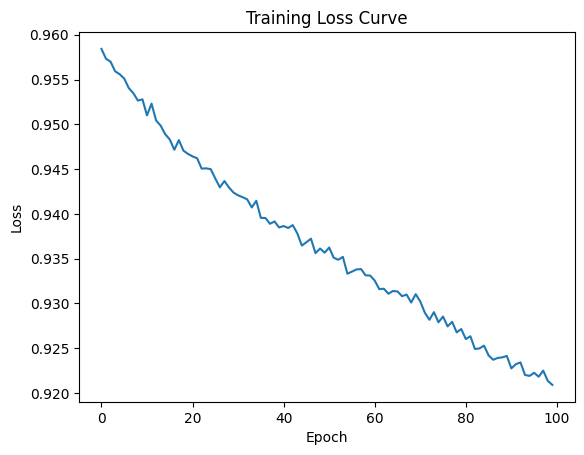

In [25]:
import matplotlib.pyplot as plt 

plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()  

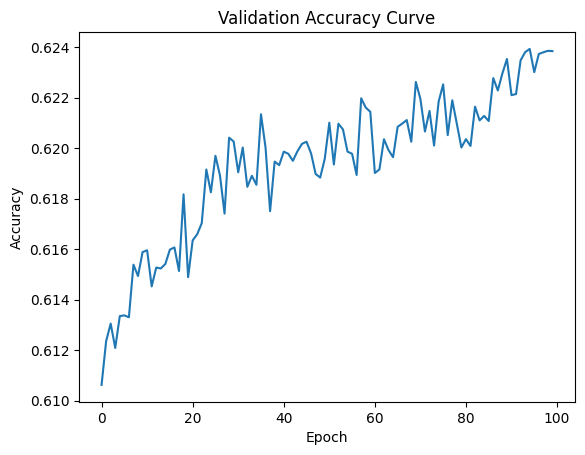

In [26]:
plt.figure()
plt.plot(accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Curve")
plt.show()

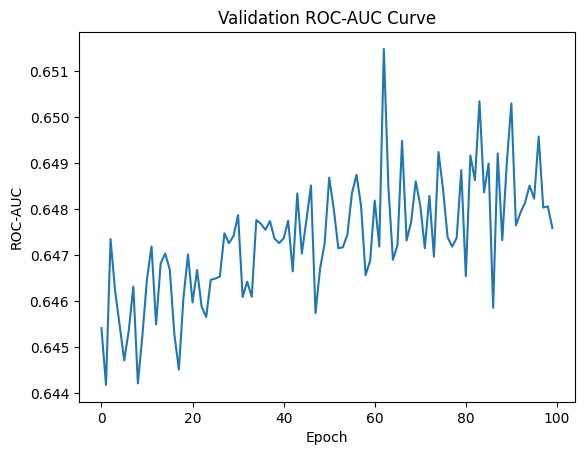

In [31]:
plt.figure()
plt.plot(auc_history)
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Validation ROC-AUC Curve")
plt.show()

### Save User Embeddings After training

In [32]:
model.eval()
with torch.no_grad():
    embeddings = model(data.x, train_edges)
    
torch.save(embeddings, "user_embeddings2.pt")

print("Embeddings saved")

Embeddings saved
